# Comparison of Nodal Prices: FBMC vs DCOPF with IP Pricing

This notebook compares nodal prices calculated using:
1. Flow-Based Market Coupling (FBMC)
2. DC Optimal Power Flow (DCOPF) with IP pricing

We'll analyze the differences between these approaches and their implications.

In [2]:
# Setup and Imports
import os
import sys
import warnings
from typing import Dict, Any

# Standard scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyPSA and IPython
import pypsa
from IPython.display import display

# Suppress warnings
warnings.filterwarnings('ignore')

# Add the project root to the path to ensure imports work
sys.path.append(os.path.abspath('..'))

# APEM imports
from execution_chain import _retrieve_data, _create_configuration
from enums import Datasets
from data.parsing.scenario import Scenario

# Allocation algorithms
from allocation.algorithms.nodal_clearing.nodal_fbmc import NodalDispatchModel
from allocation.algorithms.zonal_clearing.zonal_configuration import node_zone_mapper
from allocation.algorithms.fbmc_utils import (
    calculate_nodal_ptdf, 
    fix_missing_generator_timeseries, 
    create_pypsa_network_from_scenario
)
print("Succesful imports")

Succesful imports


In [3]:
scenario = _retrieve_data(Datasets.PyPSAEurSmall)
network_scenario = create_pypsa_network_from_scenario(scenario)
network_original = pypsa.Network("./data/raw_data/pypsa_eur_small/elec_s_40_ec_lv1.5_.nc")

INFO:pypsa.io:Imported network elec_s_40_ec_lv1.5_.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [4]:
# Load the network
nodal_ptdf_scenario = calculate_nodal_ptdf(network=network_scenario)
nodal_pddf_original = calculate_nodal_ptdf(network=network_original)

Selected the main subnetwork with 40 buses.
PTDF matrix shape: (67, 40) (lines: 67, buses: 40)
Selected the main subnetwork with 40 buses.
PTDF matrix shape: (68, 40) (lines: 68, buses: 40)


In [5]:
network_scenario = fix_missing_generator_timeseries(network_scenario)
network_original = fix_missing_generator_timeseries(network_original)


In [7]:
# Calculate FBMC nodal prices
nodal_model = NodalDispatchModel()
nodal_results_original = nodal_model.solve(network= network_original, ptdf=nodal_pddf_original, verbose=False)
nodal_results_scenario = nodal_model.solve(network= network_scenario, ptdf=nodal_ptdf_scenario, verbose=False)

Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
INFO:gurobipy:Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 53942 rows, 50208 columns and 180793 nonzeros
INFO:gurobipy:Model fingerprint: 0x60b0b595
INFO:gurobipy:Variable types: 18096 continuous, 32112 integer (32112 binary)
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [6e-05, 1e+04]
INFO:gurobipy:  Objective range  [9e-03, 1e+04]
INFO:gurobipy:  Bounds range     [1e+00, 1e+00]
INFO:gurobipy:  RHS range        [1e+00, 2e+04]
INFO:gurobipy:Found heuri

Optimal MILP solution found. Total Cost: 18073552.70


INFO:gurobipy:Warning: model has pending changes.
INFO:gurobipy:Derived model does not contain these changes.
INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 53942 rows, 50208 columns and 180793 nonzeros
INFO:gurobipy:Model fingerprint: 0x69ddebb6
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [6e-05, 1e+04]
INFO:gurobipy:  Objective range  [9e-03, 1e+04]
INFO:gurobipy:  Bounds range     [1e+00, 1e+00]
INFO:gurobipy:  RHS range        [1e+00, 2e+04]
INFO:gurobipy:Presolve removed 26003 rows and 11493 columns
INFO:gurobipy:Presolve t

Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
INFO:gurobipy:Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 30630 rows, 27144 columns and 128481 nonzeros
INFO:gurobipy:Model fingerprint: 0x30782b5a
INFO:gurobipy:Variable types: 9432 continuous, 17712 integer (17712 binary)
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e-05, 1e+04]
INFO:gurobipy:  Objective range  [9e-03, 1e+04]
INFO:gurobipy:  Bounds range     [1e+00, 1e+00]
INFO:gurobipy:  RHS range        [1e+00, 1e+04]
INFO:gurobipy:Found heuris

Optimal MILP solution found. Total Cost: 18678092.94


INFO:gurobipy:Warning: model has pending changes.
INFO:gurobipy:Derived model does not contain these changes.
INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 30630 rows, 27144 columns and 128481 nonzeros
INFO:gurobipy:Model fingerprint: 0x2165389b
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e-05, 1e+04]
INFO:gurobipy:  Objective range  [9e-03, 1e+04]
INFO:gurobipy:  Bounds range     [1e+00, 1e+00]
INFO:gurobipy:  RHS range        [1e+00, 1e+04]
INFO:gurobipy:Presolve removed 11787 rows and 1461 columns
INFO:gurobipy:Presolve ti

In [9]:
# Reset the index to turn the 'period' from an index into a column
new_model_prices_wide_original = nodal_results_original['duals']['nodal_price'].reset_index()
new_model_prices_wide_scenario = nodal_results_scenario['duals']['nodal_price'].reset_index()

# Convert the index column to the same type (use integer index)
new_model_prices_wide_original['index'] = range(1, len(new_model_prices_wide_original) + 1)
new_model_prices_wide_scenario['index'] = range(1, len(new_model_prices_wide_scenario) + 1)

# Use pd.melt to transform both DataFrames from wide to long format
new_model_prices_original = pd.melt(
    new_model_prices_wide_original,
    id_vars=['index'],
    var_name='node',
    value_name='price_fbmc_original'
)

new_model_prices_scenario = pd.melt(
    new_model_prices_wide_scenario,
    id_vars=['index'],
    var_name='node',
    value_name='price_fbmc_scenario'
)

# Merge the two FBMC price DataFrames
new_model_prices = pd.merge(
    new_model_prices_original,
    new_model_prices_scenario,
    on=['index', 'node']
)

# Multiply prices by -1 to get correct sign
new_model_prices['price_fbmc_original'] = new_model_prices['price_fbmc_original'] * -1
new_model_prices['price_fbmc_scenario'] = new_model_prices['price_fbmc_scenario'] * -1

# Rename the 'index' column to 'period' for clarity
new_model_prices.rename(columns={'index': 'period'}, inplace=True)

print("Prices from both FBMC models (long format):")
new_model_prices.head()

Prices from both FBMC models (long format):


,period,node,price_fbmc_original,price_fbmc_scenario
0,1,DE0 0,14.904368,28.207072
1,2,DE0 0,14.903841,28.207072
2,3,DE0 0,14.904062,28.207072
3,4,DE0 0,14.904584,28.207072
4,5,DE0 0,28.189080,35.993314


In [10]:

# Load the existing prices from the CSV file
path = 'C:/projekte/HiWi/APEM/results/PyPSA_Eur_Small_results/DCOPF/IP_results/IP_prices.csv'
existing_prices = pd.read_csv(path)


# Create a mapping from the integer period to the timestamp period
# This assumes the integer periods in the CSV correspond to the order of snapshots.
period_mapping = {i+1: p for i, p in enumerate(new_model_prices['period'].unique())}
existing_prices['period_timestamp'] = existing_prices['period'].map(period_mapping)

# Rename the original price column to avoid confusion after merging
existing_prices.rename(columns={'price': 'price_dcopf'}, inplace=True)


print("Prices from the existing model (with mapped timestamp):")
existing_prices.head()


Prices from the existing model (with mapped timestamp):


,node,period,price_dcopf,period_timestamp
0,DE0 0,1,28.21,1
1,DE0 0,2,28.21,2
2,DE0 0,3,28.21,3
3,DE0 0,4,28.21,4
4,DE0 0,5,34.12,5


In [12]:
comparison_df = pd.merge(
    new_model_prices,
    existing_prices[['node', 'period_timestamp', 'price_dcopf']],
    left_on=['node', 'period'],
    right_on=['node', 'period_timestamp'],
    how='left'
)

# Drop the extra timestamp column from the merge
comparison_df.drop(columns=['period_timestamp'], inplace=True)


print("Merged DataFrame for Comparison:")


comparison_df.head(10)

Merged DataFrame for Comparison:


,period,node,price_fbmc_original,price_fbmc_scenario,price_dcopf
0,1,DE0 0,14.904368,28.207072,28.21
1,2,DE0 0,14.903841,28.207072,28.21
2,3,DE0 0,14.904062,28.207072,28.21
3,4,DE0 0,14.904584,28.207072,28.21
4,5,DE0 0,28.189080,35.993314,34.12
5,6,DE0 0,28.206766,49.305707,51.23
6,7,DE0 0,28.207789,49.305707,49.31
7,8,DE0 0,28.207789,49.305707,49.31
8,9,DE0 0,28.207789,49.305707,49.31
9,10,DE0 0,28.207789,49.305707,49.31


In [17]:
# Get node value counts and display first 10
comparison_df['node'].value_counts().head(10)

node
DE0 0     24
DE0 1     24
DE0 10    24
DE0 11    24
DE0 12    24
DE0 13    24
DE0 14    24
DE0 15    24
DE0 16    24
DE0 17    24
Name: count, dtype: int64

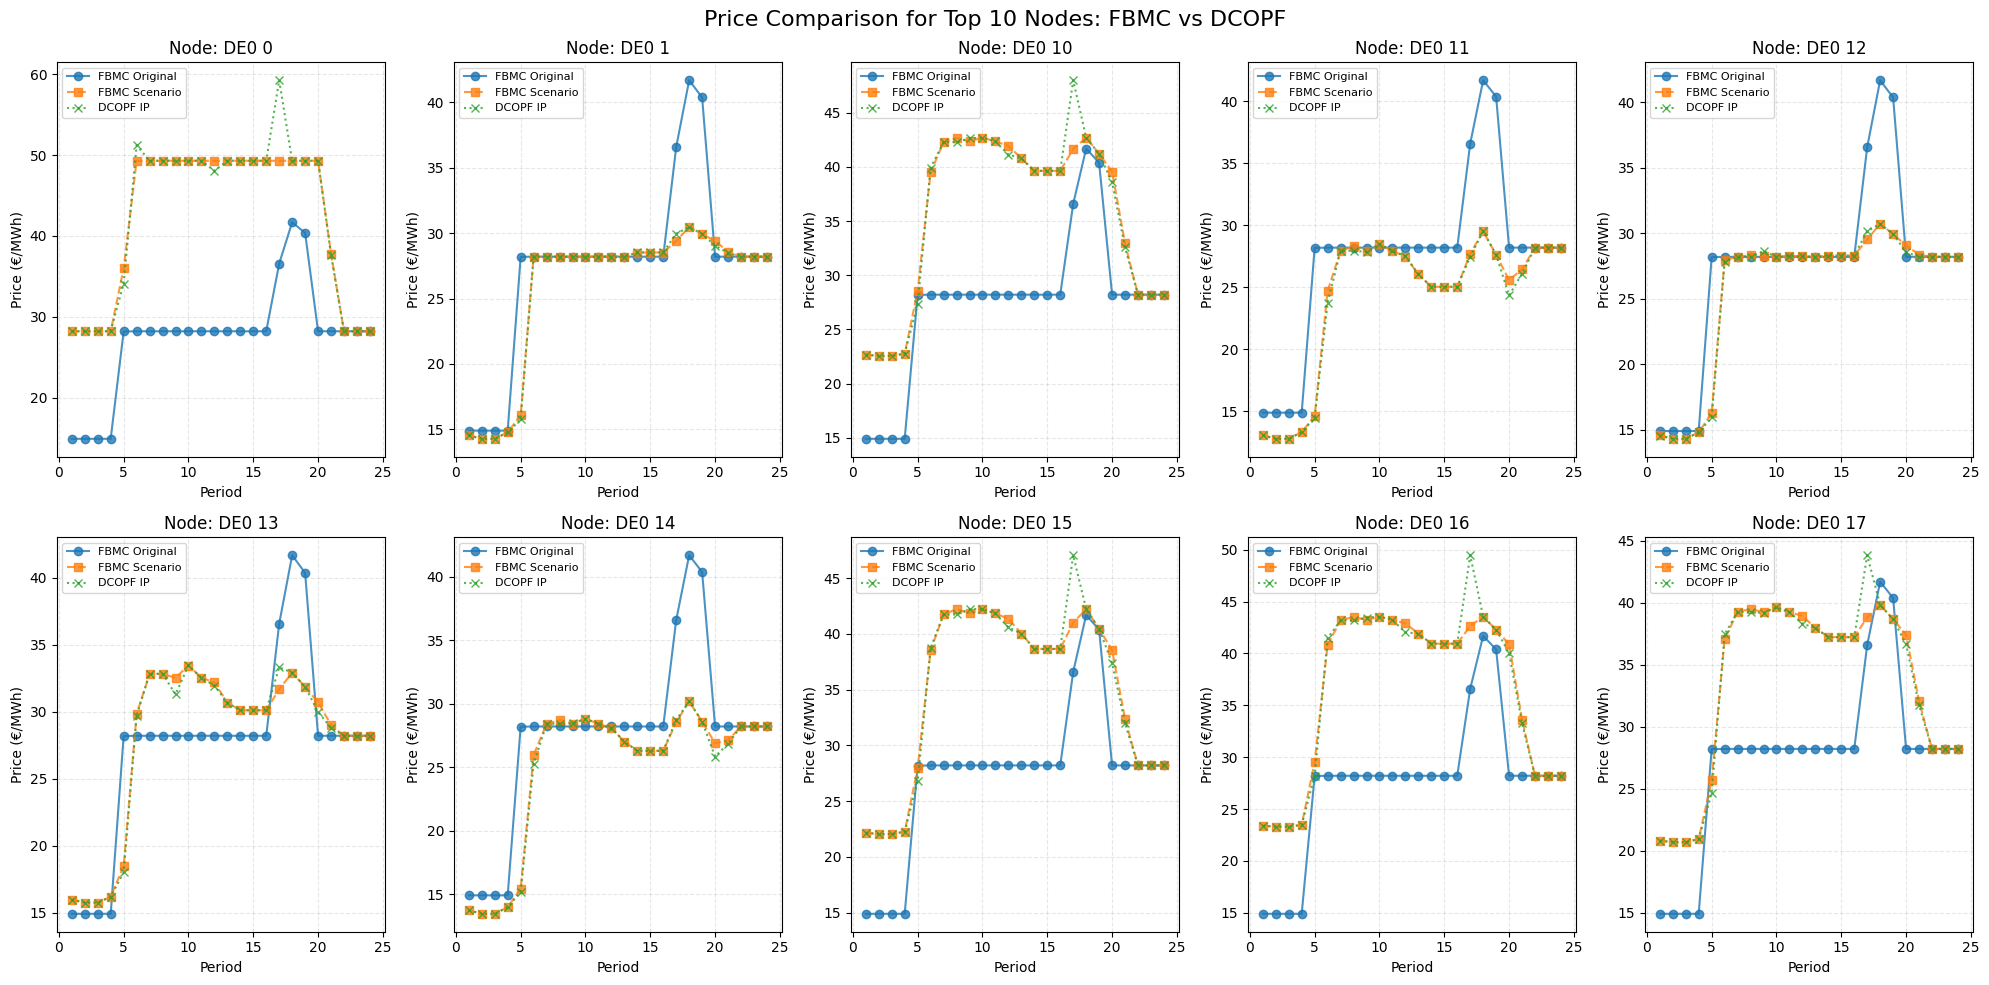

In [18]:
# Get the top 10 nodes by frequency from the previous cell
top_10_nodes = comparison_df['node'].value_counts().head(10).index.tolist()

# Calculate price differences for analysis
comparison_df['price_difference_orig_vs_dcopf'] = comparison_df['price_fbmc_original'] - comparison_df['price_dcopf']
comparison_df['price_difference_scenario_vs_dcopf'] = comparison_df['price_fbmc_scenario'] - comparison_df['price_dcopf']

# Create subplots for the top 10 nodes
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, node in enumerate(top_10_nodes):
    plot_data = comparison_df[comparison_df['node'] == node]
    
    # Plot the three price series
    axes[i].plot(plot_data['period'], plot_data['price_fbmc_original'], 
                label='FBMC Original', marker='o', linestyle='-', alpha=0.8)
    axes[i].plot(plot_data['period'], plot_data['price_fbmc_scenario'], 
                label='FBMC Scenario', marker='s', linestyle='--', alpha=0.8)
    axes[i].plot(plot_data['period'], plot_data['price_dcopf'], 
                label='DCOPF IP', marker='x', linestyle=':', alpha=0.8)
    
    # Formatting
    axes[i].set_title(f'Node: {node}', fontsize=12)
    axes[i].set_xlabel('Period', fontsize=10)
    axes[i].set_ylabel('Price (€/MWh)', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Price Comparison for Top 10 Nodes: FBMC vs DCOPF', fontsize=16)
plt.tight_layout()
plt.show()

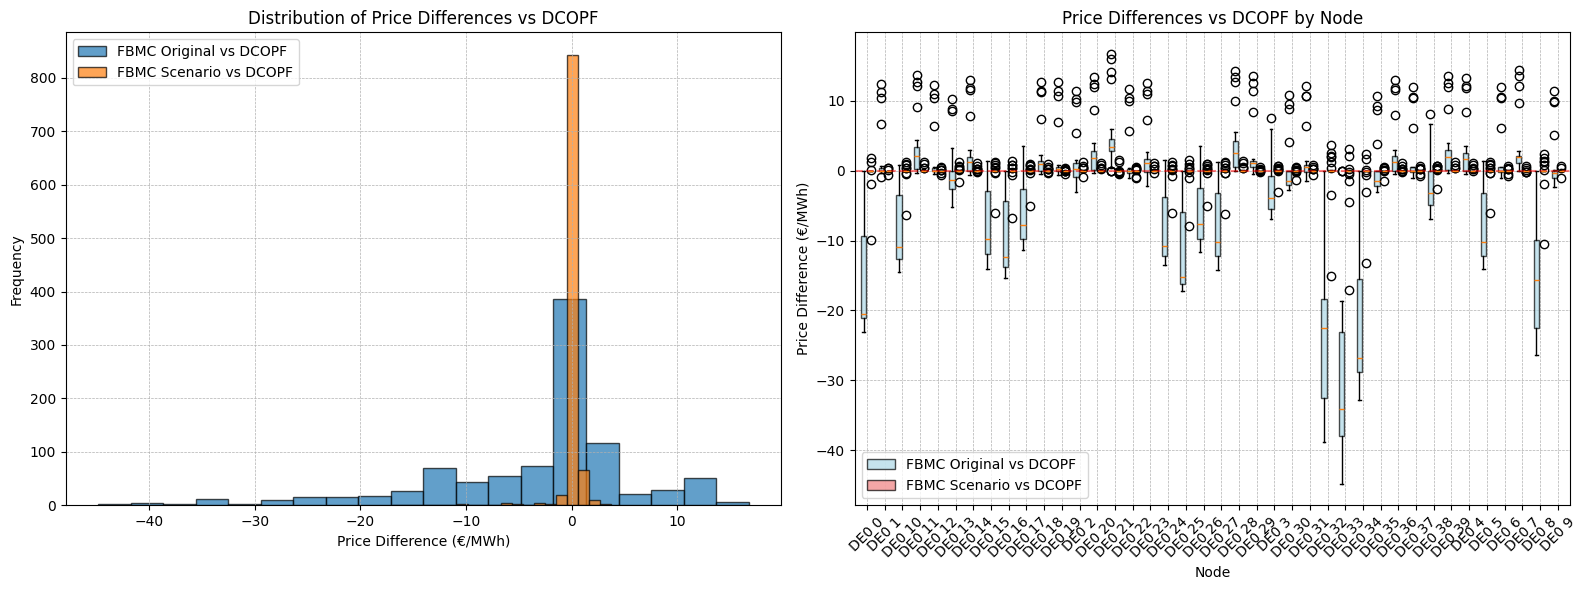

In [19]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Histogram of both price differences ---
ax1.hist(comparison_df['price_difference_orig_vs_dcopf'].dropna(), bins=20, 
         alpha=0.7, label='FBMC Original vs DCOPF', edgecolor='black')
ax1.hist(comparison_df['price_difference_scenario_vs_dcopf'].dropna(), bins=20, 
         alpha=0.7, label='FBMC Scenario vs DCOPF', edgecolor='black')
ax1.set_title('Distribution of Price Differences vs DCOPF')
ax1.set_xlabel('Price Difference (€/MWh)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, linestyle='--', linewidth=0.5)

# --- Subplot 2: Boxplot of differences per node for both models ---
nodes_unique = sorted(comparison_df['node'].unique())
orig_data = [comparison_df[comparison_df['node'] == node]['price_difference_orig_vs_dcopf'].dropna() 
             for node in nodes_unique]
scenario_data = [comparison_df[comparison_df['node'] == node]['price_difference_scenario_vs_dcopf'].dropna() 
                 for node in nodes_unique]

# Create positions for the boxplots
positions_orig = [i - 0.2 for i in range(len(nodes_unique))]
positions_scenario = [i + 0.2 for i in range(len(nodes_unique))]

bp1 = ax2.boxplot(orig_data, positions=positions_orig, widths=0.3, 
                  patch_artist=True, labels=[''] * len(nodes_unique))
bp2 = ax2.boxplot(scenario_data, positions=positions_scenario, widths=0.3, 
                  patch_artist=True, labels=[''] * len(nodes_unique))

# Color the boxplots
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)

ax2.set_title('Price Differences vs DCOPF by Node')
ax2.set_xlabel('Node')
ax2.set_ylabel('Price Difference (€/MWh)')
ax2.set_xticks(range(len(nodes_unique)))
ax2.set_xticklabels(nodes_unique, rotation=45)
ax2.legend([bp1['boxes'][0], bp2['boxes'][0]], 
           ['FBMC Original vs DCOPF', 'FBMC Scenario vs DCOPF'])
ax2.grid(True, linestyle='--', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Show the combined plot
plt.tight_layout()
plt.show()

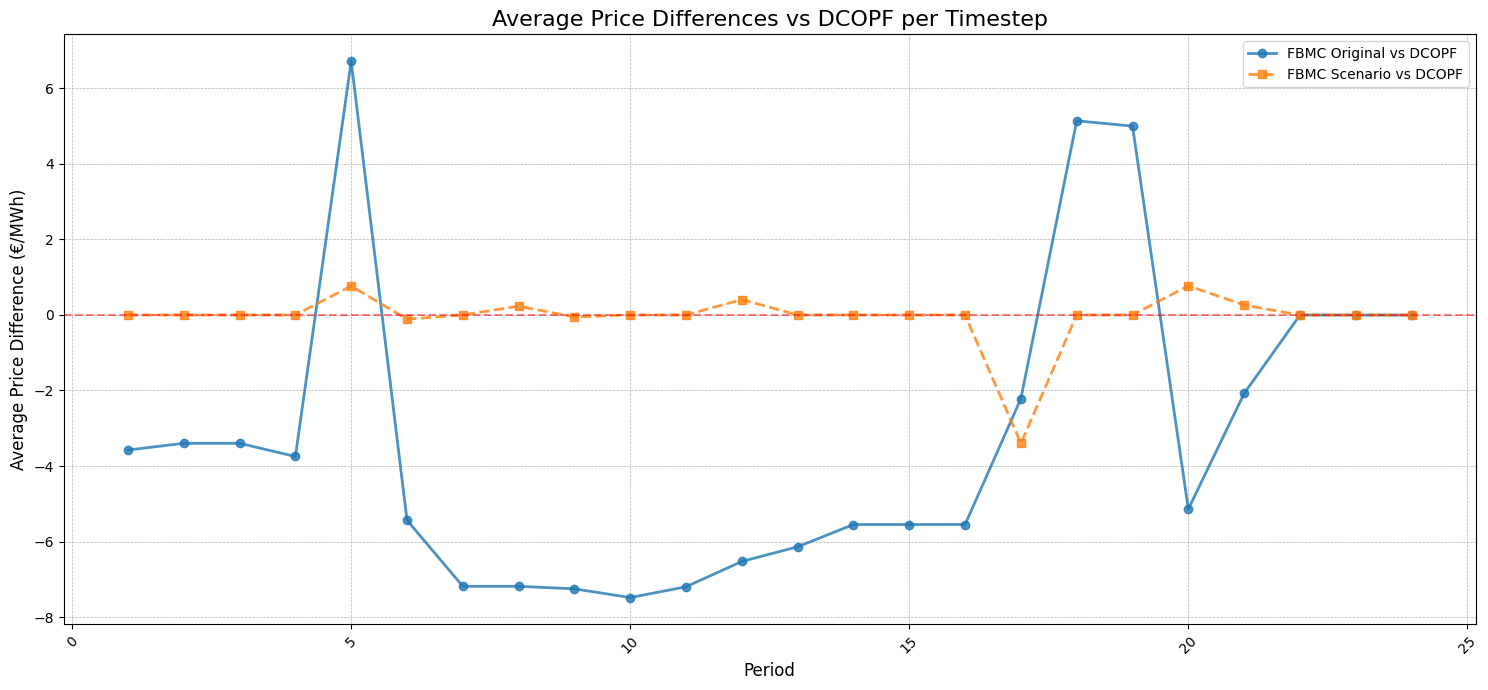


Summary Statistics of Average Price Differences per Timestep:

FBMC Original vs DCOPF:
count    24.000000
mean     -3.239787
std       4.150043
min      -7.482711
25%      -6.235336
50%      -4.444112
75%      -1.559850
max       6.720330
Name: price_difference_orig_vs_dcopf, dtype: float64

FBMC Scenario vs DCOPF:
count    24.000000
mean     -0.047416
std       0.751392
min      -3.398713
25%      -0.001499
50%      -0.000405
75%       0.000490
max       0.772024
Name: price_difference_scenario_vs_dcopf, dtype: float64


In [20]:
# Calculate average price differences per timestep for both models
avg_price_diff_orig = comparison_df.groupby('period')['price_difference_orig_vs_dcopf'].mean()
avg_price_diff_scenario = comparison_df.groupby('period')['price_difference_scenario_vs_dcopf'].mean()

# Create the plot
plt.figure(figsize=(15, 7))
plt.plot(avg_price_diff_orig.index, avg_price_diff_orig.values, 
         marker='o', linestyle='-', linewidth=2, label='FBMC Original vs DCOPF', alpha=0.8)
plt.plot(avg_price_diff_scenario.index, avg_price_diff_scenario.values, 
         marker='s', linestyle='--', linewidth=2, label='FBMC Scenario vs DCOPF', alpha=0.8)

# Formatting the plot
plt.title('Average Price Differences vs DCOPF per Timestep', fontsize=16)
plt.xlabel('Period', fontsize=12)
plt.ylabel('Average Price Difference (€/MWh)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)  # Add a reference line at y=0
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print some statistics about the average differences
print("\nSummary Statistics of Average Price Differences per Timestep:")
print("\nFBMC Original vs DCOPF:")
print(avg_price_diff_orig.describe())
print("\nFBMC Scenario vs DCOPF:")
print(avg_price_diff_scenario.describe())